# Análise Completa para Classificação de peptídeos

Este notebook apresenta uma análise completa para classificação de peptídeos utilizando métodos de machine learning. O pipeline inclui pré-processamento, extração de características, concatenação de features e modelagem preditiva.

## Estrutura do Trabalho

1. **Pré-processamento dos dados**: Análise e contagem de sequências
2. **Extração de características**: Features AAC, DPC, Complex Networks e Entropy
3. **Concatenação de features**: Unificação das características extraídas
4. **Modelagem**: Cross-validation, hyperparameter tuning e ensemble
5. **Resultados**: Predição final e geração de submission

In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier,
    ExtraTreesClassifier, 
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna

import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Pré-processamento dos Dados

Análise inicial dos conjuntos de dados para verificar a quantidade e qualidade das sequências.

In [ ]:
# Contagem de sequências nos arquivos de entrada
print("Análise dos conjuntos de dados:")
print("=" * 50)

# Sequências negativas de treino
!python ../MathFeature/preprocessing/count_sequences.py -i ../data/raw/Neg_train_fasta.fa

In [ ]:
# Sequências positivas de treino
!python ../MathFeature/preprocessing/count_sequences.py -i ../data/raw/Pos_train_fasta.fa

In [ ]:
# Sequências de teste
!python ../MathFeature/preprocessing/count_sequences.py -i ../data/raw/seqs_test.fa

In [ ]:
# Contagem de bases nas sequências positivas
print("Análise de composição de bases - Sequências Positivas:")
!python ../MathFeature/preprocessing/count_bases.py -i ../data/raw/Pos_train_fasta.fa

In [ ]:
# Contagem de bases nas sequências negativas
print("Análise de composição de bases - Sequências Negativas:")
!python ../MathFeature/preprocessing/count_bases.py -i ../data/raw/Neg_train_fasta.fa

In [ ]:
# Contagem de bases nas sequências de teste
print("Análise de composição de bases - Sequências de Teste:")
!python ../MathFeature/preprocessing/count_bases.py -i ../data/raw/seqs_test.fa

In [ ]:
# Verificação de redundância nas sequências positivas
print("Verificação de redundância - Sequências Positivas:")
!python ../MathFeature/preprocessing/remove_redundancy.py -i ../data/raw/Pos_train_fasta.fa

In [ ]:
# Verificação de redundância nas sequências negativas
print("Verificação de redundância - Sequências Negativas:")
!python ../MathFeature/preprocessing/remove_redundancy.py -i ../data/raw/Neg_train_fasta.fa

In [ ]:
# Verificação de redundância nas sequências de teste
print("Verificação de redundância - Sequências de Teste:")
!python ../MathFeature/preprocessing/remove_redundancy.py -i ../data/raw/seqs_test.fa

## 2. Extração de Características

Extração de múltiplas características das sequências utilizando o framework MathFeature.

### 2.1. Extração de AAC e DPC Features

In [ ]:
# Extração de características AAC (Amino Acid Composition) e DPC (Dipeptide Composition)
print("Extraindo características AAC e DPC...")

# AAC e DPC para sequências negativas
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ExtractionTechniques-Protein.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Neg_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/neg_processed_aac.csv -l 0 -t AAC
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ExtractionTechniques-Protein.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Neg_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/neg_processed_dpc.csv -l 0 -t DPC

# AAC e DPC para sequências positivas
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ExtractionTechniques-Protein.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Pos_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/pos_processed_aac.csv -l 1 -t AAC
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ExtractionTechniques-Protein.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Pos_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/pos_processed_dpc.csv -l 1 -t DPC

# AAC e DPC para sequências de teste
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ExtractionTechniques-Protein.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/seqs_test.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test_processed_aac.csv -l label -t AAC
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ExtractionTechniques-Protein.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/seqs_test.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test_processed_dpc.csv -l label -t DPC

### 2.2. Extração de Complex Networks Features

In [ ]:
# Extração de características baseadas em redes complexas
print("Extraindo características de Complex Networks...")

!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ComplexNetworksClass-v2.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Neg_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/neg_processed_cnc.csv -l 0 -k 3
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ComplexNetworksClass-v2.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Pos_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/pos_processed_cnc.csv -l 1 -k 3
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/ComplexNetworksClass-v2.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/seqs_test.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test_processed_cnc.csv -l label -k 3

### 2.3. Extração de Entropy Features

In [ ]:
# Extração de características baseadas em entropia de Shannon
print("Extraindo características de Entropia...")

!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/EntropyClass.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Neg_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/neg_processed_entropy.csv -l 0 -k 2 -e Shannon
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/EntropyClass.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/Pos_train_fasta.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/pos_processed_entropy.csv -l 1 -k 2 -e Shannon
!python /home/jonathan-back/code/desafio-ml-bioinfo/MathFeature/methods/EntropyClass.py -i /home/jonathan-back/code/desafio-ml-bioinfo/data/raw/seqs_test.fa -o /home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test_processed_entropy.csv -l label -k 2 -e Shannon

## 3. Concatenação das Características

Unificação de todas as características extraídas em conjuntos únicos para treino e teste.

In [ ]:
def concatenate_train_features():
    """Concatena todas as características de treino"""
    
    # Arquivos de características negativas
    neg_files = [
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/neg_processed_aac.csv',
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/neg_processed_dpc.csv', 
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/neg_processed_cnc.csv',
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/neg_processed_entropy.csv'
    ]
    
    # Arquivos de características positivas
    pos_files = [
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/pos_processed_aac.csv',
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/pos_processed_dpc.csv',
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/pos_processed_cnc.csv', 
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train/pos_processed_entropy.csv'
    ]
    
    # Concatenação horizontal das características negativas
    neg_dfs = []
    for file in neg_files:
        if os.path.exists(file):
            df = pd.read_csv(file)
            print(f"Carregado {file}: {df.shape}")
            neg_dfs.append(df)
    
    neg_combined = pd.concat(neg_dfs, axis=1)
    neg_combined = neg_combined.loc[:, ~neg_combined.columns.duplicated()]
    print(f"Características negativas combinadas: {neg_combined.shape}")
    
    # Concatenação horizontal das características positivas
    pos_dfs = []
    for file in pos_files:
        if os.path.exists(file):
            df = pd.read_csv(file)
            print(f"Carregado {file}: {df.shape}")
            pos_dfs.append(df)
    
    pos_combined = pd.concat(pos_dfs, axis=1)
    pos_combined = pos_combined.loc[:, ~pos_combined.columns.duplicated()]
    print(f"Características positivas combinadas: {pos_combined.shape}")
    
    # Concatenação vertical (neg + pos)
    train_combined = pd.concat([neg_combined, pos_combined], axis=0, ignore_index=True)
    
    # Reorganizar colunas para que 'label' seja a última
    if 'label' in train_combined.columns:
        label = train_combined.pop('label')
        train_combined.insert(len(train_combined.columns), 'label', label)
    
    # Salvar conjunto final
    train_combined.to_csv('/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/train_combined_features.csv', index=False)
    print(f"Conjunto de treino final: {train_combined.shape}")
    
    return train_combined

def concatenate_test_features():
    """Concatena todas as características de teste"""
    
    test_files = [
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test/test_processed_aac.csv',
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test/test_processed_dpc.csv',
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test/test_processed_cnc.csv', 
        '/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test/test_processed_entropy.csv'
    ]
    
    test_dfs = []
    for file in test_files:
        if os.path.exists(file):
            df = pd.read_csv(file)
            print(f"Carregado {file}: {df.shape}")
            test_dfs.append(df)
    
    test_combined = pd.concat(test_dfs, axis=1)
    test_combined = test_combined.loc[:, ~test_combined.columns.duplicated()]
    
    # Remover coluna 'label' se existir (teste não possui labels verdadeiros)
    if 'label' in test_combined.columns:
        test_combined = test_combined.drop('label', axis=1)
    
    test_combined.to_csv('/home/jonathan-back/code/desafio-ml-bioinfo/data/processed/test_combined_features.csv', index=False)
    print(f"Conjunto de teste final: {test_combined.shape}")
    
    return test_combined

# Executar concatenação
print("Concatenação de características de treino:")
print("=" * 45)
train_df = concatenate_train_features()

print("\nConcatenação de características de teste:")
print("=" * 44)  
test_df = concatenate_test_features()

print(f"\nConjuntos finais:")
print(f"Treino: {train_df.shape} - Distribuição: {train_df['label'].value_counts().to_dict()}")
print(f"Teste: {test_df.shape}")

## 4. Carregamento e Análise dos Dados

Carregamento dos conjuntos processados e análise exploratória das características.

In [10]:
# Carregamento dos dados processados
df_train = pd.read_csv("../data/processed/train_combined_features.csv")
print(f"Forma do conjunto de treino: {df_train.shape}")
print(f"Distribuição de classes:")
print(df_train['label'].value_counts())

# Separação de características e target
X_train = df_train.drop(columns=['nameseq', 'label'])
y_train = df_train['label']

print(f"Número de características: {X_train.shape[1]}")
print(f"Número de amostras: {X_train.shape[0]}")

# Carregamento dos dados de teste
df_test = pd.read_csv("../data/processed/test_combined_features.csv")
print(f"Forma do conjunto de teste: {df_test.shape}")

X_test = df_test.drop(columns=['nameseq'])
test_ids = df_test['nameseq']

print(f"Número de IDs de teste: {len(test_ids)}")

Forma do conjunto de treino: (3880, 502)
Distribuição de classes:
label
0    1940
1    1940
Name: count, dtype: int64
Número de características: 500
Número de amostras: 3880
Forma do conjunto de teste: (970, 501)
Número de IDs de teste: 970


In [11]:
# Análise e pré-processamento das características
print("Análise das características:")
print("=" * 30)
print(f"Forma dos dados: {X_train.shape}")
print(f"Valores nulos: {X_train.isnull().sum().sum()}")
print(f"Estatísticas das características:")
print(f"  Valor mínimo: {X_train.min().min():.6f}")
print(f"  Valor máximo: {X_train.max().max():.6f}")
print(f"  Média geral: {X_train.mean().mean():.6f}")
print(f"  Desvio padrão médio: {X_train.std().mean():.6f}")

# Verificação de características com variância zero
zero_var_features = X_train.columns[X_train.var() == 0]
if len(zero_var_features) > 0:
    print(f"Características com variância zero: {len(zero_var_features)}")
    X_train = X_train.drop(columns=zero_var_features)
    X_test = X_test.drop(columns=zero_var_features)
    print(f"Forma após remoção: {X_train.shape}")

print(f"Utilizando características na escala original para compatibilidade com modelos tree-based")
print(f"Forma final dos dados: {X_train.shape}")

Análise das características:
Forma dos dados: (3880, 500)
Valores nulos: 0
Estatísticas das características:
  Valor mínimo: -1.000000
  Valor máximo: 1741.000000
  Média geral: 1.608977
  Desvio padrão médio: 2.312608
Utilizando características na escala original para compatibilidade com modelos tree-based
Forma final dos dados: (3880, 500)


## 4.5. Seleção de Features com SelectKBest

Aplicação de seleção de características para identificar as features mais importantes e avaliar impacto na performance.

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler

print("Seleção de Features Mais Importantes:")
print("=" * 40)

# Testar diferentes números de features
k_values = [50, 100, 200, 300, 400, 508]  # 508 é o total
feature_selection_results = []

# Normalizar dados para chi2 (requer valores não-negativos)
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Testar diferentes métodos de seleção
selection_methods = {
    'f_classif': f_classif,
    'mutual_info': mutual_info_classif,
    'chi2': chi2
}

best_method = None
best_k = None
best_score = 0
best_features = None

print("Testando seleção de features com diferentes métodos e valores de K:")
print()

for method_name, score_func in selection_methods.items():
    print(f"Método: {method_name}")
    print("-" * 30)
    
    for k in k_values:
        if k > X_train.shape[1]:
            k = X_train.shape[1]
            
        # Selecionar features
        if method_name == 'chi2':
            # Chi2 requer valores não-negativos
            selector = SelectKBest(score_func=score_func, k=k)
            X_train_selected = selector.fit_transform(X_train_normalized, y_train)
        else:
            selector = SelectKBest(score_func=score_func, k=k)
            X_train_selected = selector.fit_transform(X_train, y_train)
        
        # Testar com modelo rápido (LightGBM)
        quick_model = LGBMClassifier(
            n_estimators=50, 
            random_state=42, 
            verbose=-1,
            force_col_wise=True
        )
        
        # Validação cruzada rápida
        cv_quick = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(quick_model, X_train_selected, y_train, cv=cv_quick, scoring='balanced_accuracy')
        mean_score = scores.mean()
        
        result = {
            'method': method_name,
            'k': k,
            'score': mean_score,
            'std': scores.std()
        }
        feature_selection_results.append(result)
        
        print(f"  K={k:3d}: {mean_score:.4f} (±{scores.std():.4f})")
        
        # Armazenar melhor configuração
        if mean_score > best_score:
            best_score = mean_score
            best_method = method_name
            best_k = k
            best_features = selector
    
    print()

print(f"Melhor configuração encontrada:")
print(f"  Método: {best_method}")
print(f"  K: {best_k}")
print(f"  Score: {best_score:.4f}")
print(f"  Melhoria vs. todas features: {(best_score - feature_selection_results[-1]['score'])*100:+.2f}%")

Seleção de Features Mais Importantes:
Testando seleção de features com diferentes métodos e valores de K:

Método: f_classif
------------------------------
  K= 50: 0.8131 (±0.0062)
  K=100: 0.8235 (±0.0091)
  K=200: 0.8351 (±0.0067)
  K=300: 0.8376 (±0.0101)
  K=400: 0.8454 (±0.0069)
  K=500: 0.8479 (±0.0103)

Método: mutual_info
------------------------------
  K= 50: 0.7755 (±0.0101)
  K=100: 0.8214 (±0.0057)
  K=200: 0.8423 (±0.0103)
  K=300: 0.8438 (±0.0043)
  K=400: 0.8407 (±0.0095)
  K=500: 0.8479 (±0.0103)

Método: chi2
------------------------------
  K= 50: 0.8090 (±0.0127)
  K=100: 0.8343 (±0.0075)
  K=200: 0.8340 (±0.0058)
  K=300: 0.8420 (±0.0113)
  K=400: 0.8420 (±0.0103)
  K=500: 0.8451 (±0.0041)

Melhor configuração encontrada:
  Método: f_classif
  K: 500
  Score: 0.8479
  Melhoria vs. todas features: +0.28%


In [15]:
# Aplicar a melhor seleção de features encontrada
if best_k < X_train.shape[1]:  # Só aplicar se realmente selecionou features
    print(f"\nAplicando seleção de features: {best_method} com K={best_k}")
    
    # Recriar o melhor seletor
    if best_method == 'chi2':
        best_selector = SelectKBest(score_func=chi2, k=best_k)
        X_train_selected = best_selector.fit_transform(X_train_normalized, y_train)
        X_test_selected = best_selector.transform(X_test_normalized)
    else:
        score_func = selection_methods[best_method]
        best_selector = SelectKBest(score_func=score_func, k=best_k)
        X_train_selected = best_selector.fit_transform(X_train, y_train)
        X_test_selected = best_selector.transform(X_test)
    
    # Atualizar os datasets para usar features selecionadas
    X_train_original = X_train.copy()
    X_test_original = X_test.copy()
    
    X_train = pd.DataFrame(X_train_selected)
    X_test = pd.DataFrame(X_test_selected)
    
    print(f"Features selecionadas: {X_train.shape[1]} de {X_train_original.shape[1]}")
    
    # Mostrar as features mais importantes
    selected_features = X_train_original.columns[best_selector.get_support()]
    feature_scores = best_selector.scores_[best_selector.get_support()]
    
    # Criar DataFrame com features e scores
    feature_importance_df = pd.DataFrame({
        'Feature': selected_features,
        'Score': feature_scores
    }).sort_values('Score', ascending=False)
    
    print(f"\nTop 10 features mais importantes:")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Visualização das features mais importantes
    plt.figure(figsize=(12, 6))
    top_features = feature_importance_df.head(20)
    plt.barh(range(len(top_features)), top_features['Score'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel(f'Score ({best_method})')
    plt.title('Top 20 Features Mais Importantes')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
else:
    print("Todas as features foram mantidas (melhor resultado)")
    X_train_selected = X_train
    X_test_selected = X_test

Todas as features foram mantidas (melhor resultado)


## 5. Modelagem - Baseline com Cross-Validation

Avaliação de múltiplos modelos utilizando validação cruzada estratificada.

In [16]:
# Configuração da validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definição dos modelos tree-based
models = {
    'LightGBM': LGBMClassifier(
        n_estimators=100, 
        random_state=42, 
        verbose=-1,
        n_jobs=-1, 
        force_col_wise=True
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, 
        random_state=42, 
        eval_metric='logloss',
        n_jobs=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100,
        random_state=42,
        verbose=0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    'Histogram GB': HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        random_state=42
    )
}

# Armazenamento dos resultados
results = []

print("Avaliação dos modelos com validação cruzada (5-fold):")
print("=" * 55)

for name, model in models.items():
    print(f"Avaliando {name}...")
    
    # Validação cruzada com múltiplas métricas
    scores_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    scores_roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    results.append({
        'Modelo': name,
        'Accuracy': scores_acc.mean(),
        'Accuracy_std': scores_acc.std(),
        'F1-Score': scores_f1.mean(),
        'F1_std': scores_f1.std(),
        'ROC-AUC': scores_roc.mean(),
        'ROC_std': scores_roc.std()
    })
    
    print(f"  Accuracy: {scores_acc.mean():.4f} (±{scores_acc.std():.4f})")
    print(f"  F1-Score: {scores_f1.mean():.4f} (±{scores_f1.std():.4f})")
    print(f"  ROC-AUC:  {scores_roc.mean():.4f} (±{scores_roc.std():.4f})")

Avaliação dos modelos com validação cruzada (5-fold):
Avaliando LightGBM...
  Accuracy: 0.8528 (±0.0085)
  F1-Score: 0.8514 (±0.0091)
  ROC-AUC:  0.9309 (±0.0058)
Avaliando XGBoost...
  Accuracy: 0.8510 (±0.0064)
  F1-Score: 0.8501 (±0.0069)
  ROC-AUC:  0.9286 (±0.0046)
Avaliando CatBoost...
  Accuracy: 0.8363 (±0.0086)
  F1-Score: 0.8358 (±0.0095)
  ROC-AUC:  0.9167 (±0.0065)
Avaliando Random Forest...
  Accuracy: 0.8268 (±0.0024)
  F1-Score: 0.8247 (±0.0040)
  ROC-AUC:  0.9133 (±0.0052)
Avaliando AdaBoost...
  Accuracy: 0.7296 (±0.0135)
  F1-Score: 0.7047 (±0.0201)
  ROC-AUC:  0.8136 (±0.0120)
Avaliando Extra Trees...
  Accuracy: 0.8446 (±0.0048)
  F1-Score: 0.8413 (±0.0054)
  ROC-AUC:  0.9275 (±0.0063)
Avaliando Gradient Boosting...
  Accuracy: 0.8332 (±0.0104)
  F1-Score: 0.8312 (±0.0101)
  ROC-AUC:  0.9108 (±0.0052)
Avaliando Histogram GB...
  Accuracy: 0.8539 (±0.0061)
  F1-Score: 0.8526 (±0.0064)
  ROC-AUC:  0.9311 (±0.0041)


In [18]:
# Apresentação dos resultados em tabela
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('ROC-AUC', ascending=False)
print("Resultados da avaliação baseline (ordenados por ROC-AUC):")
print("=" * 60)
print(df_results.to_string(index=False))

Resultados da avaliação baseline (ordenados por ROC-AUC):
           Modelo  Accuracy  Accuracy_std  F1-Score   F1_std  ROC-AUC  ROC_std
     Histogram GB  0.853866      0.006132  0.852594 0.006431 0.931126 0.004102
         LightGBM  0.852835      0.008525  0.851380 0.009138 0.930853 0.005783
          XGBoost  0.851031      0.006448  0.850075 0.006909 0.928591 0.004579
      Extra Trees  0.844588      0.004794  0.841253 0.005412 0.927521 0.006256
         CatBoost  0.836340      0.008587  0.835821 0.009465 0.916746 0.006490
    Random Forest  0.826804      0.002390  0.824676 0.004001 0.913332 0.005219
Gradient Boosting  0.833247      0.010425  0.831225 0.010103 0.910781 0.005160
         AdaBoost  0.729639      0.013550  0.704739 0.020070 0.813594 0.011965


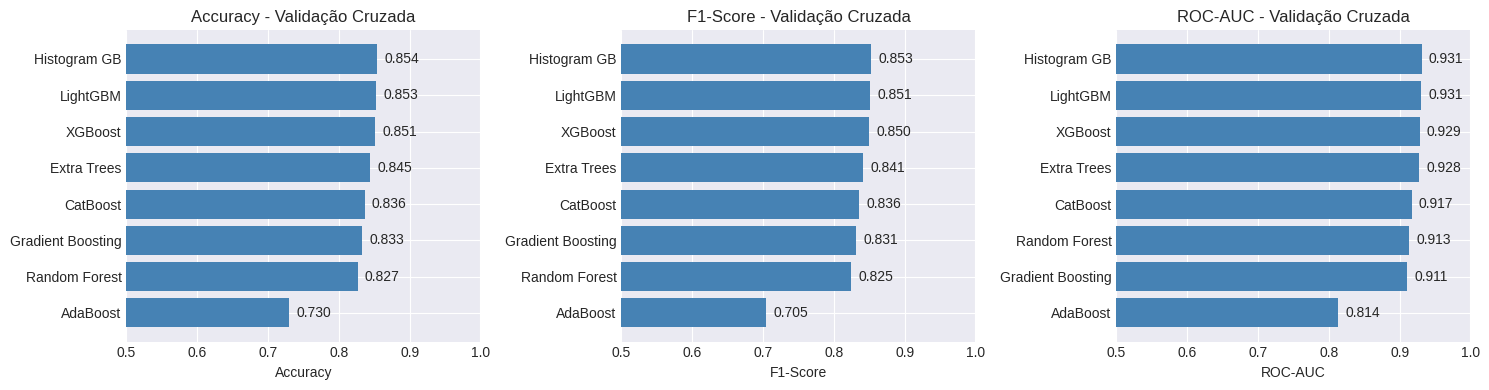

Melhor modelo (ROC-AUC): Histogram GB


In [19]:
# Visualização comparativa dos resultados
os.makedirs('../results', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(['Accuracy', 'F1-Score', 'ROC-AUC']):
    ax = axes[idx]
    df_plot = df_results.sort_values(metric, ascending=True)
    ax.barh(df_plot['Modelo'], df_plot[metric], color='steelblue')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} - Validação Cruzada')
    ax.set_xlim([0.5, 1.0])
    
    # Anotação dos valores
    for i, v in enumerate(df_plot[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('../results/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Melhor modelo (ROC-AUC): {df_results.iloc[0]['Modelo']}")

## 6. Hyperparameter Tuning com Optuna

Otimização bayesiana dos hiperparâmetros dos melhores modelos.

In [22]:
print("Otimização de hiperparâmetros dos modelos tree-based:")
print("=" * 55)

# Funções objetivo para otimização com parâmetros amplos e completos
def objective_lgbm(trial):
    # Primeiro definir o boosting_type para determinar parâmetros compatíveis
    boosting_type = trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss'])
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.2, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 200),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-5, 100.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 100.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 500),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'subsample_for_bin': trial.suggest_int('subsample_for_bin', 20000, 300000),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'boosting_type': boosting_type,
        'random_state': 42,
        'verbose': -1,
        'force_col_wise': True,
        'n_jobs': -1
    }
    
    # Parâmetros condicionais baseados no boosting_type
    if boosting_type == 'dart':
        # DART permite bagging
        params['bagging_fraction'] = trial.suggest_float('bagging_fraction', 0.3, 1.0)
        params['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 10)
        params['drop_rate'] = trial.suggest_float('drop_rate', 0.1, 0.5)
        params['max_drop'] = trial.suggest_int('max_drop', 5, 50)
        params['skip_drop'] = trial.suggest_float('skip_drop', 0.2, 0.8)
    elif boosting_type == 'gbdt':
        # GBDT permite bagging
        params['bagging_fraction'] = trial.suggest_float('bagging_fraction', 0.3, 1.0)
        params['bagging_freq'] = trial.suggest_int('bagging_freq', 1, 10)
    # GOSS não permite bagging - não adicionamos bagging_fraction nem bagging_freq
    
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.3, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.2, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 100.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 100.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'gamma': trial.suggest_float('gamma', 0.0, 2.0),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2.0),
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        'tree_method': trial.suggest_categorical('tree_method', ['auto', 'exact', 'approx', 'hist']),
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    
    # Parâmetros condicionais
    if params['grow_policy'] == 'lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 10, 1000)
    
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

def objective_histgb(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 50, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
        'max_bins': trial.suggest_int('max_bins', 32, 255),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 0.0, 10.0),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 1000),
        'early_stopping': trial.suggest_categorical('early_stopping', [True, False]),
        'scoring': trial.suggest_categorical('scoring', ['loss', 'accuracy']),
        'random_state': 42
    }
    
    # Parâmetros condicionais para early stopping
    if params['early_stopping']:
        params['validation_fraction'] = trial.suggest_float('validation_fraction', 0.1, 0.3)
        params['n_iter_no_change'] = trial.suggest_int('n_iter_no_change', 5, 20)
        params['tol'] = trial.suggest_float('tol', 1e-7, 1e-3, log=True)

    model = HistGradientBoostingClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 50),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.3, 0.5, 0.8]),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 1000),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Parâmetros condicionais
    if not params['bootstrap']:
        params['oob_score'] = False
        params['max_samples'] = trial.suggest_float('max_samples', 0.3, 1.0)
    else:
        params['oob_score'] = trial.suggest_categorical('oob_score', [True, False])

    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 2000),
        'depth': trial.suggest_int('depth', 3, 16),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 100.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 50),
        'leaf_estimation_method': trial.suggest_categorical('leaf_estimation_method', ['Newton', 'Gradient']),
        'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
        'class_weights': trial.suggest_categorical('class_weights', [None, [1, 1], [1, 2], [2, 1]]),
        'random_state': 42,
        'verbose': 0
    }
    
    # Parâmetros condicionais
    if params['bootstrap_type'] == 'Bernoulli':
        params['subsample'] = trial.suggest_float('subsample', 0.3, 1.0)
    elif params['bootstrap_type'] == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 10.0)
        
    if params['grow_policy'] == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 10, 1000)

    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='balanced_accuracy')
    return scores.mean()

# Configuração da otimização ampliada
optimization_config = {
    'LightGBM': {'func': objective_lgbm, 'trials': 300, 'timeout': 5400},
    'XGBoost': {'func': objective_xgb, 'trials': 300, 'timeout': 5400}, 
    'Histogram GB': {'func': objective_histgb, 'trials': 300, 'timeout': 5400},
    'Random Forest': {'func': objective_rf, 'trials': 250, 'timeout': 4500},
    'CatBoost': {'func': objective_catboost, 'trials': 250, 'timeout': 4500},
}

optimized_models = {}
optimized_scores = {}
baseline_scores = {}

# Extração dos scores baseline para comparação
for result in results:
    baseline_scores[result['Modelo']] = result['Accuracy']

print(f"Iniciando otimização de {len(optimization_config)} modelos...")

for model_name, config in optimization_config.items():
    print(f"Otimizando {model_name} ({config['trials']} trials, {config['timeout']}s timeout)...")
    
    study = optuna.create_study(
        direction='maximize', 
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=10)
    )
    
    study.optimize(
        config['func'], 
        n_trials=config['trials'], 
        timeout=config['timeout'],
        show_progress_bar=True
    )
    
    baseline_score = baseline_scores.get(model_name, 0)
    improvement = (study.best_value - baseline_score) * 100
    
    print(f"  Baseline: {baseline_score:.4f}")
    print(f"  Otimizado: {study.best_value:.4f}")
    print(f"  Melhoria: {improvement:+.2f}%")
    
    optimized_scores[model_name] = study.best_value
    optimized_models[model_name] = study.best_params

# Ranking dos modelos otimizados
print("\nRanking final dos modelos otimizados:")
print("=" * 40)

sorted_models = sorted(optimized_scores.items(), key=lambda x: x[1], reverse=True)

for i, (model_name, score) in enumerate(sorted_models, 1):
    baseline_score = baseline_scores.get(model_name, 0)
    improvement = (score - baseline_score) * 100
    print(f"{i}. {model_name}: {score:.4f} (melhoria: {improvement:+.2f}%)")

print("\nTop 3 modelos otimizados:")
top3_optimized = [name for name, _ in sorted_models[:3]]
for i, name in enumerate(top3_optimized, 1):
    score = optimized_scores[name]
    print(f"  {i}. {name}: {score:.4f}")

[I 2025-11-18 20:05:07,050] A new study created in memory with name: no-name-4d994908-6e35-4b0c-95c1-41b4aee465c8


Otimização de hiperparâmetros dos modelos tree-based:
Iniciando otimização de 5 modelos...
Otimizando LightGBM (300 trials, 5400s timeout)...


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2025-11-18 20:05:11,704] Trial 0 finished with value: 0.8028350515463917 and parameters: {'boosting_type': 'dart', 'n_estimators': 1217, 'max_depth': 7, 'learning_rate': 0.010255552094216988, 'feature_fraction': 0.24646688973455957, 'min_child_samples': 174, 'min_child_weight': 0.16136341713591323, 'reg_alpha': 0.12042752972516801, 'reg_lambda': 1.6063676259174453e-08, 'num_leaves': 486, 'min_split_gain': 0.8324426408004217, 'subsample_for_bin': 79455, 'class_weight': 'balanced', 'bagging_fraction': 0.5129695700716763, 'bagging_freq': 6, 'drop_rate': 0.2727780074568463, 'max_drop': 18, 'skip_drop': 0.5671117368334277}. Best is trial 0 with value: 0.8028350515463917.
[I 2025-11-18 20:05:14,389] Trial 1 finished with value: 0.8170103092783505 and parameters: {'boosting_type': 'goss', 'n_estimators': 939, 'max_depth': 24, 'learning_rate': 0.01254057843022616, 'feature_fraction': 0.6113875507308892, 'min_child_samples': 119, 'min_child_weight': 2.114233203549714e-05, 'reg_alpha': 0.0118

[I 2025-11-18 21:16:04,099] A new study created in memory with name: no-name-fe4659c6-9acc-4234-8f6d-23918847af50


[I 2025-11-18 21:16:04,096] Trial 299 finished with value: 0.8605670103092784 and parameters: {'boosting_type': 'goss', 'n_estimators': 1835, 'max_depth': 9, 'learning_rate': 0.022779567366355925, 'feature_fraction': 0.6918516596742387, 'min_child_samples': 8, 'min_child_weight': 0.00024378533960829306, 'reg_alpha': 5.388364521113908e-05, 'reg_lambda': 2.8601686061634602e-05, 'num_leaves': 421, 'min_split_gain': 0.0007222835703794422, 'subsample_for_bin': 43356, 'class_weight': 'balanced'}. Best is trial 278 with value: 0.8716494845360824.
  Baseline: 0.8528
  Otimizado: 0.8716
  Melhoria: +1.88%
Otimizando XGBoost (300 trials, 5400s timeout)...


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2025-11-18 21:16:33,632] Trial 0 finished with value: 0.8167525773195876 and parameters: {'n_estimators': 780, 'max_depth': 29, 'learning_rate': 0.14553179565665345, 'subsample': 0.7190609389379257, 'colsample_bytree': 0.3248149123539492, 'colsample_bylevel': 0.32479561626896214, 'colsample_bynode': 0.24646688973455957, 'reg_alpha': 4.589458612326471, 'reg_lambda': 0.010260065124896791, 'min_child_weight': 36, 'gamma': 0.041168988591604894, 'max_delta_step': 10, 'scale_pos_weight': 1.7486639612006325, 'grow_policy': 'depthwise', 'tree_method': 'approx'}. Best is trial 0 with value: 0.8167525773195876.
[I 2025-11-18 21:16:38,729] Trial 1 finished with value: 0.7987113402061855 and parameters: {'n_estimators': 618, 'max_depth': 20, 'learning_rate': 0.009505122659935179, 'subsample': 0.5045012539746527, 'colsample_bytree': 0.4930894746349534, 'colsample_bylevel': 0.5648559873736287, 'colsample_bynode': 0.8281407691144109, 'reg_alpha': 9.925166969962287e-07, 'reg_lambda': 0.001387855925

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/jonathan-back/code/desafio-ml-bioinfo/.venv/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/jonathan-back/code/desafio-ml-bioinfo/.venv/lib/python3.11/site-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/jonathan-back/code/desafio-ml-bioinfo/.venv/lib/python3.11/site-packages/xgboost/sklearn.py", line 1803, in fit
    self._Booster = train(
                    ^^^^^^
  File "/home/jonathan-back/code/desafio-ml-bioinfo/.venv/lib/python3.11/site-package

## 7. Ensemble dos Modelos Otimizados

Criação de ensemble com os três melhores modelos otimizados.

In [ ]:
print("Ensemble dos modelos otimizados:")
print("=" * 35)

# Seleção dos top 3 modelos otimizados
top3_optimized_names = [name for name, _ in sorted_models[:3]]

print("Modelos selecionados para ensemble:")
for i, name in enumerate(top3_optimized_names, 1):
    score = optimized_scores[name]
    print(f"  {i}. {name}: {score:.4f}")

# Criação dos modelos otimizados para ensemble
ensemble_models_optimized = []

for name in top3_optimized_names:
    print(f"Configurando {name} otimizado...")
    
    if name == 'LightGBM':
        model = LGBMClassifier(**optimized_models[name])
    elif name == 'XGBoost':
        model = XGBClassifier(**optimized_models[name])
    elif name == 'CatBoost':
        model = CatBoostClassifier(**optimized_models[name])
    elif name == 'Random Forest':
        model = RandomForestClassifier(**optimized_models[name])
    elif name == 'Histogram GB':
        model = HistGradientBoostingClassifier(**optimized_models[name])
    elif name == 'Extra Trees':
        model = ExtraTreesClassifier(**optimized_models[name])
    elif name == 'AdaBoost':
        model = AdaBoostClassifier(**optimized_models[name])
    elif name == 'Gradient Boosting':
        model = GradientBoostingClassifier(**optimized_models[name])
    else:
        continue
    
    ensemble_models_optimized.append((name.lower().replace(' ', ''), model))

# Avaliação do ensemble vs melhor modelo individual
if len(ensemble_models_optimized) >= 2:
    ensemble_optimized = VotingClassifier(
        estimators=ensemble_models_optimized,
        voting='soft',
        n_jobs=-1
    )

    print(f"Avaliando ensemble com {len(ensemble_models_optimized)} modelos...")
    scores_acc_opt = cross_val_score(ensemble_optimized, X_train, y_train, cv=cv, scoring='balanced_accuracy')

    print(f"Resultado do ensemble otimizado: {scores_acc_opt.mean():.4f} (±{scores_acc_opt.std():.4f})")

    # Comparação com melhor modelo individual
    best_individual_optimized = max(optimized_scores.values())
    improvement_ensemble = (scores_acc_opt.mean() - best_individual_optimized) * 100

    print("Comparação ensemble vs melhor individual:")
    print(f"  Melhor individual: {best_individual_optimized:.4f}")
    print(f"  Ensemble: {scores_acc_opt.mean():.4f}")
    print(f"  Diferença: {improvement_ensemble:+.2f}%")

    # Seleção do modelo final
    if scores_acc_opt.mean() > best_individual_optimized:
        print("Modelo final selecionado: Ensemble otimizado")
        final_model = ensemble_optimized
        final_model_name = f"Ensemble-Otimizado({'+'.join(top3_optimized_names)})"
        final_accuracy = scores_acc_opt.mean()
    else:
        print("Modelo final selecionado: Melhor individual otimizado")
        best_name = max(optimized_scores, key=optimized_scores.get)
        
        if best_name == 'LightGBM':
            final_model = LGBMClassifier(**optimized_models[best_name])
        elif best_name == 'XGBoost':
            final_model = XGBClassifier(**optimized_models[best_name])
        elif best_name == 'Histogram GB':
            final_model = HistGradientBoostingClassifier(**optimized_models[best_name])
        
        final_model_name = f"{best_name}-Otimizado"
        final_accuracy = optimized_scores[best_name]
else:
    # Fallback para melhor modelo individual
    best_model_name = top3_optimized_names[0]
    print(f"Utilizando melhor modelo individual: {best_model_name}")
    
    if best_model_name == 'LightGBM':
        final_model = LGBMClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'XGBoost':
        final_model = XGBClassifier(**optimized_models[best_model_name])
    elif best_model_name == 'Histogram GB':
        final_model = HistGradientBoostingClassifier(**optimized_models[best_model_name])
    
    final_model_name = f"{best_model_name}-Otimizado"
    final_accuracy = optimized_scores[best_model_name]

print(f"\nModelo final selecionado: {final_model_name}")
print(f"Balanced Accuracy (CV): {final_accuracy:.4f}")

## 8. Predição Final e Geração de Submission

Treinamento do modelo final e geração das predições para o conjunto de teste.

In [ ]:
print("Predição final com modelo otimizado:")
print("=" * 40)

# Configurações finais
X_test_final = X_test
print(f"Conjunto de treino: {X_train.shape}")
print(f"Conjunto de teste: {X_test_final.shape}")

# Verificação de compatibilidade
if X_train.shape[1] != X_test_final.shape[1]:
    raise ValueError(f"Incompatibilidade: treino {X_train.shape[1]} vs teste {X_test_final.shape[1]} características")

print(f"Treinando modelo final: {final_model_name}")
print(f"Balanced Accuracy esperada: {final_accuracy:.4f}")

# Treinamento com conjunto completo
final_model.fit(X_train, y_train)
print("Modelo treinado com sucesso")

# Geração de predições
print("Gerando predições para conjunto de teste...")
y_test_pred = final_model.predict(X_test_final)
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

print(f"Predições geradas: {len(y_test_pred)}")

# Análise das predições
print("\nAnálise das predições:")
print(f"  Classe 0 (Negativo): {(y_test_pred == 0).sum():,} ({(y_test_pred == 0).mean()*100:.1f}%)")
print(f"  Classe 1 (Positivo): {(y_test_pred == 1).sum():,} ({(y_test_pred == 1).mean()*100:.1f}%)")

print(f"\nEstatísticas das probabilidades:")
print(f"  Média: {y_test_proba.mean():.3f}")
print(f"  Mínimo: {y_test_proba.min():.3f}")
print(f"  Máximo: {y_test_proba.max():.3f}")
print(f"  Desvio padrão: {y_test_proba.std():.3f}")

# Validação da distribuição
expected_pos_rate = y_train.mean()
actual_pos_rate = y_test_pred.mean()
distribution_diff = (actual_pos_rate - expected_pos_rate) * 100

print(f"\nValidação da distribuição:")
print(f"  Taxa classe 1 no treino: {expected_pos_rate:.3f} ({expected_pos_rate*100:.1f}%)")
print(f"  Taxa classe 1 predita: {actual_pos_rate:.3f} ({actual_pos_rate*100:.1f}%)")
print(f"  Diferença: {distribution_diff:+.1f} pontos percentuais")

# Criação dos arquivos de submission
submission = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred
})

submission_proba = pd.DataFrame({
    'ID': test_ids,
    'TARGET': y_test_pred,
    'PROBABILITY': y_test_proba
})

# Salvamento dos resultados
os.makedirs('../results', exist_ok=True)
submission_path = Path('../results/submission_optimized.csv')
submission_proba_path = Path('../results/submission_optimized_with_proba.csv')

submission.to_csv(submission_path, index=False)
submission_proba.to_csv(submission_proba_path, index=False)

print(f"\nArquivos de submission gerados:")
print(f"  Principal: {submission_path}")
print(f"  Com probabilidades: {submission_proba_path}")

print(f"\nResumo do modelo final:")
print(f"  Modelo: {final_model_name}")
print(f"  Balanced Accuracy: {final_accuracy:.4f}")
print(f"  Total de predições: {len(submission):,}")

print(f"\nPrimeiras 10 predições:")
print(submission.head(10).to_string(index=False))

print(f"\nAnálise completa finalizada com sucesso")

## 9. Visualizações e Análise Detalhada dos Resultados

Análise visual completa do desempenho dos modelos e qualidade das predições.

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict, cross_validate
import matplotlib.pyplot as plt
import seaborn as sns

print("Análise Detalhada do Modelo Final:")
print("=" * 40)

# Obter predições e probabilidades via validação cruzada para análise mais robusta
print("Gerando predições via validação cruzada para análise...")
cv_predictions = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict')
cv_probabilities = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

# Métricas detalhadas
print("\nRelatório de Classificação (Validação Cruzada):")
print("=" * 50)
print(classification_report(y_train, cv_predictions, target_names=['Negativo', 'Positivo']))

# Matriz de Confusão
plt.figure(figsize=(15, 5))

# Subplot 1: Matriz de Confusão
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_train, cv_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predito Negativo', 'Predito Positivo'],
            yticklabels=['Real Negativo', 'Real Positivo'])
plt.title('Matriz de Confusão\n(Validação Cruzada)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Predita')

# Calcular métricas da matriz de confusão
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
precision = tp / (tp + fp)
npv = tn / (tn + fn)

print(f"\nMétricas da Matriz de Confusão:")
print(f"  Verdadeiros Negativos (TN): {tn}")
print(f"  Falsos Positivos (FP): {fp}")
print(f"  Falsos Negativos (FN): {fn}")
print(f"  Verdadeiros Positivos (TP): {tp}")
print(f"  Sensibilidade (Recall): {sensitivity:.4f}")
print(f"  Especificidade: {specificity:.4f}")
print(f"  Precisão: {precision:.4f}")
print(f"  Valor Preditivo Negativo: {npv:.4f}")

# Subplot 2: Curva ROC
plt.subplot(1, 3, 2)
fpr, tpr, thresholds = roc_curve(y_train, cv_probabilities)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC\n(Validação Cruzada)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 3: Distribuição de Probabilidades
plt.subplot(1, 3, 3)
prob_positive = cv_probabilities[y_train == 1]
prob_negative = cv_probabilities[y_train == 0]

plt.hist(prob_negative, bins=30, alpha=0.7, label='Classe Negativa', color='lightcoral', density=True)
plt.hist(prob_positive, bins=30, alpha=0.7, label='Classe Positiva', color='lightblue', density=True)
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Probabilidade Predita')
plt.ylabel('Densidade')
plt.title('Distribuição de Probabilidades\n(Validação Cruzada)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/detailed_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAUC-ROC: {roc_auc:.4f}")
print(f"Threshold ótimo baseado em Youden's J: {thresholds[np.argmax(tpr - fpr)]:.4f}")

In [ ]:
# Análises adicionais: Curva Precision-Recall e Calibração
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve

plt.figure(figsize=(15, 5))

# Subplot 1: Curva Precision-Recall
plt.subplot(1, 3, 1)
precision, recall, pr_thresholds = precision_recall_curve(y_train, cv_probabilities)
ap_score = average_precision_score(y_train, cv_probabilities)

plt.plot(recall, precision, color='blue', lw=2, 
         label=f'PR Curve (AP = {ap_score:.4f})')
plt.axhline(y=y_train.mean(), color='red', linestyle='--', 
           label=f'Baseline (AP = {y_train.mean():.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Calibração do modelo
plt.subplot(1, 3, 2)
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_train, cv_probabilities, n_bins=10, strategy='uniform'
)

plt.plot(mean_predicted_value, fraction_of_positives, "s-", 
         label=f'{final_model_name}', linewidth=2, markersize=8)
plt.plot([0, 1], [0, 1], "k:", label="Calibração Perfeita")
plt.xlabel('Probabilidade Média Predita')
plt.ylabel('Fração de Positivos')
plt.title('Calibração do Modelo')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Feature Importance (se disponível)
plt.subplot(1, 3, 3)
try:
    # Tentar obter importância das features
    if hasattr(final_model, 'feature_importances_'):
        importances = final_model.feature_importances_
    elif hasattr(final_model, 'estimators_'):
        # Para ensemble, pegar a média das importâncias
        importances = np.mean([est.feature_importances_ for name, est in final_model.estimators_], axis=0)
    else:
        importances = None
    
    if importances is not None:
        # Pegar top 20 features mais importantes
        indices = np.argsort(importances)[::-1][:20]
        
        plt.barh(range(len(indices)), importances[indices])
        plt.yticks(range(len(indices)), [f'Feature_{i}' for i in indices])
        plt.xlabel('Importância')
        plt.title('Top 20 Features Mais Importantes')
        plt.gca().invert_yaxis()
    else:
        plt.text(0.5, 0.5, 'Feature Importance\nnão disponível\npara este modelo', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('Feature Importance')
        plt.xticks([])
        plt.yticks([])
        
except Exception as e:
    plt.text(0.5, 0.5, f'Erro ao calcular\nFeature Importance:\n{str(e)}', 
            ha='center', va='center', transform=plt.gca().transAxes, fontsize=10)
    plt.title('Feature Importance')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.savefig('../results/advanced_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage Precision Score: {ap_score:.4f}")

# Análise de threshold
print(f"\nAnálise de Thresholds:")
print("=" * 25)
thresholds_analysis = []
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_thresh = (cv_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred_thresh).ravel()
    
    precision_thresh = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_thresh = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_thresh = 2 * (precision_thresh * recall_thresh) / (precision_thresh + recall_thresh) if (precision_thresh + recall_thresh) > 0 else 0
    
    thresholds_analysis.append({
        'Threshold': threshold,
        'Precision': precision_thresh,
        'Recall': recall_thresh,
        'F1-Score': f1_thresh,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })
    
    print(f"Threshold {threshold:.1f}: Precision={precision_thresh:.4f}, Recall={recall_thresh:.4f}, F1={f1_thresh:.4f}")

# Converter para DataFrame para melhor visualização
thresh_df = pd.DataFrame(thresholds_analysis)
print(f"\nTabela de Análise de Thresholds:")
print(thresh_df.to_string(index=False))